In [73]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss
import pandas as pd
from scipy.stats import binom
import plotly.graph_objects as go
from scipy.special import gamma, beta,digamma,comb
import scipy.optimize as so
from scipy.stats import zipf
import scipy.stats as sstat



## Constant-Weight-Code
All the code here is related to the old report. It contains an application of the Constant weight code to some plausible input distribution (Shakespeare letters occurence.)

1) Generate a uniform and a power law dataset
2) Define optimal N and A
3) Compute the cost for different $beta$ 


## Non-uniform case

In [74]:
## Fit Zipfs distribution with curve fit
def zipf_f(x,alpha):
    return zipf.pmf(x,alpha,loc=0)
    
def gamma_f(x,alpha,theta):
    return sstat.gamma.pdf(x,alpha,loc=0,scale=theta)

#### Test if sum of freq=1 :  True
[1.09675001]
[ 0.66378302 38.77109566]


Text(0, 0.5, 'Frequency')

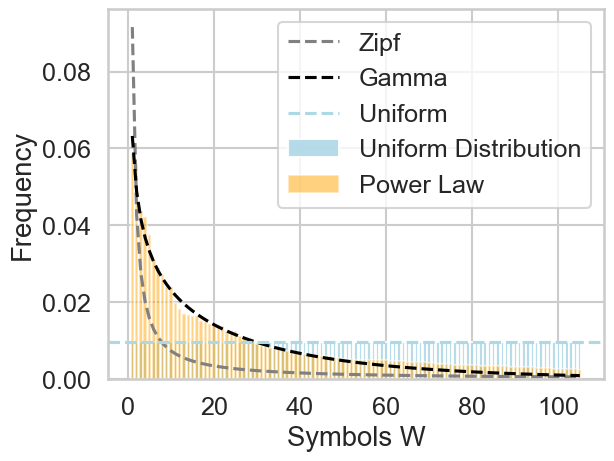

In [75]:
## Power Law using https://data.world/tronovan/shakespeare-word-frequencies/workspace/file?filename=shakes_charts.ipynb


W=105


DFshak = pd.read_csv('shakespeare.csv')
DFshak = DFshak.rename(columns={DFshak.columns[0]:'count',DFshak.columns[1]:'word'})
## Only assume the first W words and normalize accoriding to it
Total_wshak=DFshak['count'][:W].sum()
DFshak['frequency']=DFshak['count']/Total_wshak
DFshak.head()
power_d=np.array(DFshak['frequency'][:W])
print("#### Test if sum of freq=1 : ",np.isclose(power_d.sum(),1))

## Uniform Distribution
uniform_d=np.zeros(W)+1/W

x=np.arange(1,W+1) # start at 1 to fit with the zeta distribution

## Fit Zipfs distribution with curve fit
zeta_fit=so.curve_fit(zipf_f,x,power_d,p0=[1.001])
print(zeta_fit[0])

## fits Gamma 

gamma_fit_l=so.curve_fit(gamma_f,x,power_d)
print(gamma_fit_l[0])

## Plot Two distributions
plt_range=W
plt.bar(x[:plt_range],uniform_d[:plt_range],alpha=0.9,label='Uniform Distribution',color='lightblue')
plt.bar(x[:plt_range],power_d[:plt_range],alpha=0.5,label='Power Law',color='orange')
plt.plot(x[:plt_range],zipf_f(x,zeta_fit[0][0]),linestyle='--',color='grey',label='Zipf')
plt.plot(x[:plt_range],gamma_f(x,gamma_fit_l[0][0],gamma_fit_l[0][1]),linestyle='--',color='black',label='Gamma')

#plt.plot(x[:plt_range],np.exp(b2)*x[:plt_range]**alpha2,linestyle='-.',color='black',label='Exp fit')
plt.axhline(y=uniform_d[0],linestyle='--',color='lightblue',label='Uniform')
plt.legend()
plt.xlabel('Symbols W')
plt.ylabel('Frequency')

## Presentation Uniform Input Distribution

In [76]:
## Optimal Code with corrected cost

def gamma_fit(pw,W):
    x=np.arange(1,W+1)
    gamma_fit=so.curve_fit(gamma_f,x,pw)
    return gamma_fit[0]

def zipf_fit(pw,W):
    x=np.arange(1,W+1)
    zeta_fit=so.curve_fit(zipf_f,x,pw,p0=[1.001])
    return zeta_fit[0]

def findN(W):
    print("--search lower bound N")
    N=np.ceil(np.log2(W))
    return N

def BinomialCDF(N):
    Bin_cdf=[]
    for aj in range(0,N+1):
        bin_interm=[int(ss.binom(N,k)) for k in range(0,aj+1)]
        Bin_cdf.append(np.sum(bin_interm)/2**N) # divide by 2**N to reach 1 at end of cdf
    Pascal=bin_interm
    return Bin_cdf,Pascal

def Generate_Alpha(A,CW_used):
    """
    Generate the Alpha vector for the optimal code
    A: number of activation
    CW_used: codewords used in the optimal code
    """
    Alpha=[]
    for aj in range(0,A+1): # +1 because want to reach Afinal
        # Save alpha vector
        Value=int(aj)
        intemr=np.zeros(CW_used[aj])+Value
        Alpha=np.concatenate((Alpha,intemr))
    return Alpha

def return_beta_uniform(Ni,Ai,N2,A2,W):
    superior=W*(N2-Ni)
    bin_i=[ss.binom(Ni,ai) for ai in range(0,Ai+1)]
    bin_2=[ss.binom(N2,a2) for a2 in range(0,A2+1)]
    bin_a_i=[ai*bin_i[i_test] for i_test,ai in enumerate(range(0,Ai+1))]
    bin_a_2=[a2*bin_2[i_test] for i_test,a2 in enumerate(range(0,A2+1))]
    inferior=(np.sum(bin_a_i)-Ai*(np.sum(bin_i)-W))-(np.sum(bin_a_2)-A2*(np.sum(bin_2)-W))

    return superior/inferior

def Min_sign_flip_close(B,beta_Deriv_all):
    idx_close_zero=np.zeros(len(B))
    for i,bi in enumerate(B):
        der=np.array(beta_Deriv_all[i])
        equal_z=np.where(der==0)[0]
        if len(equal_z)>0: # case the derivative is zero
            idx_close_zero[i]=equal_z[0]
        else :
            sign_changes = np.where((der[:-1] < 0) & (der[1:]> 0))
            #print(sign_changes[0][0])
            if len(sign_changes[0])>0 & len(equal_z)==0:
                # Take the 1st flip
                neg_to_pos_val=[sign_changes[0][0],sign_changes[0][0]+1]
                #print(der[neg_to_pos_val])
                best_val=np.argmin(np.abs(der[neg_to_pos_val]))
                #print(best_val)
                idx_close_zero[i]=neg_to_pos_val[best_val]
    return idx_close_zero

def return_beta_gamma_approx(Ni,Ai,N2,A2,W,gam_param):
    superior=(1-ss.gammaincc(gam_param[0],(W)/gam_param[1]))*(N2-Ni)
    K_interm_i=0
    for aj in range(0,Ai+1): # +1 because want to reach Afinal
        Value=int(aj)
        indexes_down=[ss.binom(Ni,ai) for ai in range(0,aj)]
        index_down_f=np.sum(indexes_down)+1
        indexes_up=[ss.binom(Ni,ai) for ai in range(0,aj+1)]
        index_up_f=np.sum(indexes_up)  
        K_interm_i+=Value*(ss.gammaincc(gam_param[0],index_down_f/gam_param[1])-ss.gammaincc(gam_param[0],index_up_f/gam_param[1]))    
    
    K_interm_i-=Ai*(ss.gammaincc(gam_param[0],(W+1)/gam_param[1])-ss.gammaincc(gam_param[0],index_up_f/gam_param[1]))
    
    K_interm_2=0
    for aj in range(0,A2+1): # +1 because want to reach Afinal
        Value=int(aj)
        indexes_down2=[ss.binom(N2,ai) for ai in range(0,aj)]
        index_down_f2=np.sum(indexes_down2)+1
        indexes_up2=[ss.binom(N2,ai) for ai in range(0,aj+1)]
        index_up_f2=np.sum(indexes_up2)  
        K_interm_2+=Value*(ss.gammaincc(gam_param[0],index_down_f2/gam_param[1])-ss.gammaincc(gam_param[0],index_up_f2/gam_param[1]))    
    
    K_interm_2-=A2*(ss.gammaincc(gam_param[0],(W+1)/gam_param[1])-ss.gammaincc(gam_param[0],index_up_f2/gam_param[1]))
    
    inferior=K_interm_i-K_interm_2
    
    return superior/inferior

def return_beta_gamma_true(Ni,Ai,CW_used_i,N2,A2,CW_used_2,Pw):
    All_alpha_i=Generate_Alpha(Ai,CW_used_i)
    All_alpha_2=Generate_Alpha(A2,CW_used_2)
    superior=(N2-Ni)*np.sum(Pw)
    interm=[Pw[i]*(All_alpha_i[i]-All_alpha_2[i]) for i in range(0,len(All_alpha_i))]
    inferior=np.sum(interm)

    return superior/inferior

def kappa(gam_par_zeta,x_interm,n_interm,a_interm):
    chain=ss.binom(n_interm,a_interm)*(digamma(n_interm+1)-digamma(n_interm+1-a_interm))
    kap=(-pow(x_interm,gam_par_zeta-1)*np.exp(-x_interm))/gamma(gam_par_zeta)
    return kap*chain



def OptimalCode_general_corrected(W,N=0,beta=1,pw=0,type_dist='Uniform',test_bool=False,N_modif_bool=True):
    tst=test_bool
    N_modif=N_modif_bool # approximation impact the geometry of the cost of A and N
    
    if N==0:
        print('---no N as input')
        N=int(findN(W))
    Bin_cdf,Pascal=BinomialCDF(N)
    # Compute Lower bound (Formula 8-9 Intermediate report)
    Optimal_cdf=np.array([Bin_cdf_i-W/2**N for Bin_cdf_i in Bin_cdf]) # Formula 9 in Intermediate report
    Optimal_cdf[Optimal_cdf<0]=np.nan # delete all Case where we would have not enough Symbols (A too small) (can't use abs else if W=160 and N,A gives 157, it will be closest but not enough symbols)
    A=np.nanargmin(Optimal_cdf)
    CW_used=[Pascal_i for Pascal_i in Pascal[:int(A)]] # Keep all binomial except last activation
    CW_used.append(W-np.sum(CW_used)) # Fullfil the last layer with just enough codewords

    ## Generate Alpha
    Alpha=Generate_Alpha(A,CW_used)

    ## Saving
    Supp_mat={}
    
    ## Sum W cost
    Cost_A_W=[]
    for i,wi in enumerate(range(0,W)):
        Cost_A_W.append(pw[i]*Alpha[i])
    Cost_N_W=N*np.sum(pw)
    Supp_mat['Cost_A_per_W']=Cost_A_W
    if tst:
        print("## Test sum pw = 1:", np.isclose(np.sum(pw),1))
    Cost_total_W=beta*np.sum(Cost_A_W)+Cost_N_W


    ## Fit a Distribtuion 
    if type_dist=="Gamma":
        gam_param=gamma_fit(pw,W) # [alpha,theta]
        Supp_mat['gam_param']=gam_param

    ## Sum A cost A
    cost_A_interm=[]
    full_CW=[]
    # for Uniform
    der_1st=0
    der_2nd=0
    # for Bounded
    z_j=[]
    # for Gamma
    indexes_up=[]
    indexes_down=[]
    Q_i=[]
    for aj in range(0,A+1): # +1 because want to reach Afinal
        Value=int(aj)
        full_CW.append(ss.binom(N,aj))
        #Compute cost
        if type_dist=='Uniform':
            cost_A_interm.append(Value*ss.binom(N,aj))
            # Compute derrivative
            der_value=ss.binom(N,aj)*(digamma(N+1)-digamma(N+1-aj))
            der_1st+=Value*der_value
            der_2nd+=der_value
        elif type_dist=='Bounded': ## !! here we look at indexes thus it is -1 since python starts indexing at 0
            index_z=(np.sum(full_CW[:-1])+1)-1 # -1 because Pyhton start indexing at 0
            #print("index_z",index_z)
            z_j.append(pw[int(index_z)])
            cost_A_interm.append(Value*ss.binom(N,aj)*pw[int(index_z)])
            # Compute derrivative
            der_value=ss.binom(N,aj)*(digamma(N+1)-digamma(N+1-aj))
            der_1st+=Value*der_value*pw[int(index_z)]
            der_2nd+=der_value
        elif type_dist=='Zeta':
            print('#### Error Zeta not Yet implemented')
        elif type_dist=='Gamma': ## !! Here indexes are actual values --> no -1
            indexes_down.append(np.sum(full_CW[:-1])) 
            indexes_up.append(np.sum(full_CW))                
            #print(indexes_down[-1],indexes_up[-1])
            Q_i.append(ss.gammaincc(gam_param[0],indexes_down[-1]/gam_param[1])-ss.gammaincc(gam_param[0],indexes_up[-1]/gam_param[1]))
            cost_A_interm.append(Value*Q_i[-1])
            #derivative
            kap_1=kappa(gam_param[0],indexes_down[-1]/gam_param[1],N,aj)
            kap_2=kappa(gam_param[0],indexes_up[-1]/gam_param[1],N,aj)
            der_1st+=Value*(kap_1-kap_2)
            der_2nd=kap_2 # the last iteration will correspond to the correct value
        else:
            print('#### Error Please specify a distribution : Uniform Bounded Zeta Gamma')
    
    #Cost Total
    Cost_A_A=0
    Cost_N_A=0
    dC_dN_A=0
    
    diff_corr=np.sum(full_CW)-W # corrector

    if type_dist=='Uniform':
        Cost_N_A=N
        Cost_per_A=[ca*beta*pw[0] for ca in cost_A_interm]
        Cost_per_A[-1]=Cost_per_A[-1]-(beta*pw[0]*A*diff_corr) ##correct the last A
        Cost_A_A=np.sum(Cost_per_A)
        #Derivative
        dC_dN_A=beta*pw[0]*(der_1st-A*der_2nd)+1
        Supp_mat['Cost_A_per_A']=Cost_per_A
    elif type_dist=='Bounded':
        ###Equation 29 report 2
        if N_modif:
            Cost_N_A=N*np.sum(z_j[-1]) 
            #Derivative
            dC_dN_A=beta*(der_1st-A*der_2nd*z_j[-1])+np.sum(z_j[-1])

        else:
            Cost_N_A=N
            #Derivative
            dC_dN_A=beta*(der_1st-A*der_2nd*z_j[-1])+1

        Cost_per_A=[ca*beta for ca in cost_A_interm]
        Cost_per_A[-1]=Cost_per_A[-1]-(beta*z_j[-1]*A*diff_corr) ##correct the last A
        Cost_A_A=np.sum(Cost_per_A)
    
        Supp_mat['z_j']=z_j
        Supp_mat['Cost_A_per_A']=Cost_per_A
    elif type_dist=='Zeta':
        print('### Zeta distribution not implemented')
    elif type_dist=='Gamma':
        final_idx_used=np.sum(full_CW) 
        #print("final index",final_idx_used)
        Q_correct=ss.gammaincc(gam_param[0],(W)/gam_param[1])-ss.gammaincc(gam_param[0],final_idx_used/gam_param[1])        
        Cost_per_A=[ca*beta for ca in cost_A_interm]
        Cost_per_A[-1]=Cost_per_A[-1]-(beta*Q_correct*A) ##correct the last A
        Supp_mat['Cost_A_per_A']=Cost_per_A
        Cost_A_A=np.sum(Cost_per_A) #=beta*(np.sum(cost_A_interm)-A*Q_correct) 

        if tst:
            print("## Test Correct implementation of P(0<=x<=Xf)")
            q_0_f=ss.gammaincc(gam_param[0],0/gam_param[1])-ss.gammaincc(gam_param[0],final_idx_used/gam_param[1])       
            print("Step by step: ",np.sum(Q_i))
            print("One step calculation: ",q_0_f)
            q_0_w=ss.gammaincc(gam_param[0],0/gam_param[1])-ss.gammaincc(gam_param[0],(W)/gam_param[1])       
            print("## Test Correct implementation of P(0<=x<=W)")
            print("Step by step: ",np.sum(Q_i)-Q_correct)
            print("One step calculation: ",q_0_w)

        ###Equation 29 report 2
        if N_modif:
            Cost_N_A=N*(1-ss.gammaincc(gam_param[0],(W)/gam_param[1])) 
            dC_dN_A=(beta*(der_1st-A*der_2nd))+(1-ss.gammaincc(gam_param[0],(W)/gam_param[1])) 

        else:
            Cost_N_A=N
            dC_dN_A=beta*(der_1st-A*der_2nd)+1

        ####


    Cost_Total_A=Cost_A_A+Cost_N_A

    # In case we run the function with a non-uniform distribution in order to obtain the cost dep on W (should not happens)
    if type_dist=='Uniform':
        if pw[0]!=pw[-1]: 
            print("#####--- ERROR Your distribution is not uniform ---#####")
            return 
    
    if tst:
        print("## Test Sum W vs Sum A:", np.isclose(Cost_Total_A,Cost_total_W))
    return N,A,CW_used,full_CW,Cost_Total_A,dC_dN_A,Cost_total_W,Supp_mat

In [77]:
# Difference cost per activations 

N_u,A_u,CW_used_u,full_CW_u,Cost_Total_A_u,dC_dN_A_u,Cost_total_W_u,Sup_mat_u=OptimalCode_general_corrected(W,N=0,beta=1,pw=uniform_d,type_dist='Uniform')


---no N as input
--search lower bound N


Text(0, 0.5, 'Cost')

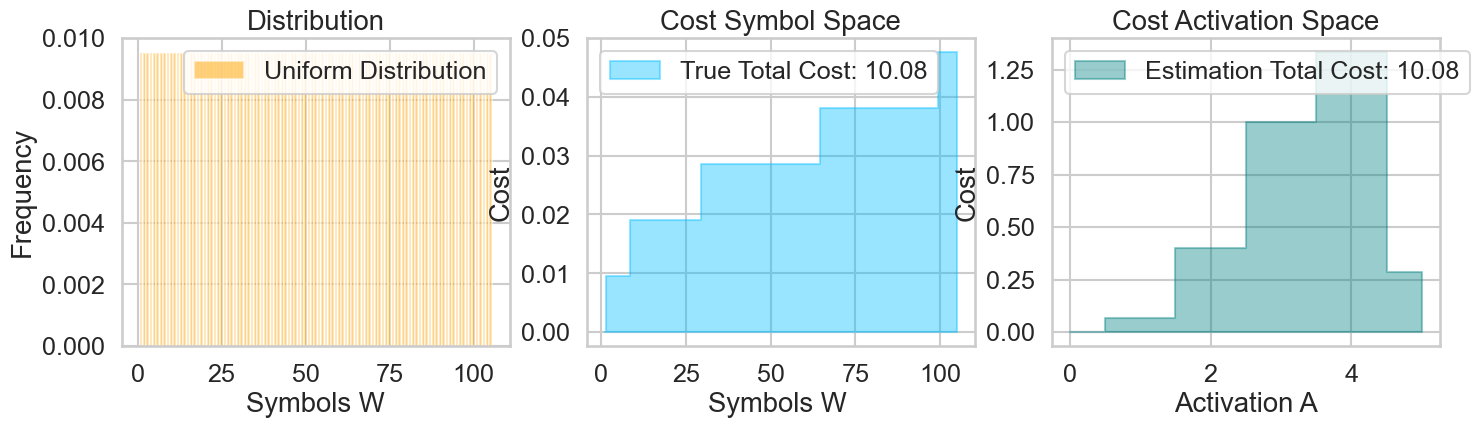

In [78]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4))

axs[0].bar(x[:plt_range],uniform_d[:plt_range],alpha=0.5,label='Uniform Distribution',color='orange')
#axs[0].plot(x[:plt_range],uni_proba_bounded,linestyle='-.',color='black',label='bounded')
axs[0].legend()
axs[0].set_xlabel('Symbols W')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Distribution')

label_uni="True Total Cost: "+str(Cost_total_W_u)[0:5]
#axs[1].plot(x[:plt_range],Sup_mat_u['Cost_A_W'],color='black')
axs[1].fill_between(x[:plt_range], Sup_mat_u['Cost_A_per_W'], step="mid", alpha=0.4,color='deepskyblue',label=label_uni)
axs[1].legend(loc='upper left')
axs[1].set_title('Cost Symbol Space')
axs[1].set_xlabel('Symbols W ')
axs[1].set_ylabel('Cost')

label_A="Estimation Total Cost: "+str(Cost_Total_A_u)[0:5]
#axs[2].plot(range(0,A_ub+1),Sup_mat_ub['Cost_per_A'],label=label_bounded,color='deepskyblue',linestyle='dashed')
axs[2].fill_between(range(0,A_u+1), Sup_mat_u['Cost_A_per_A'], step="mid", alpha=0.4,color='teal',label=label_A)

axs[2].legend(loc='upper left')
axs[2].set_title('Cost Activation Space')
axs[2].set_xlabel('Activation A')
axs[2].set_ylabel('Cost')

In [79]:
# Test code beta separation
w_test=8
beta_test_true=[4,8]
beta_test=[]
set_test=[(3,3),(4,2),(7,1)]
for j_test in range(len(set_test)):
    if j_test<len(set_test)-1:
        beta_test.append(return_beta_uniform(set_test[j_test][0],set_test[j_test][1],set_test[j_test+1][0],set_test[j_test+1][1],w_test))
print("#### Test Beta ####",beta_test==beta_test_true)


#### Test Beta #### True


# Power Law Uniform


In [80]:
## Power law Bounded

## !!! The Power law is N_modif_bool=False because I am unsure if I implemented it correclty (I think I should do N*zj*number of elements having a!!!
N_eb,A_eb,CW_used_eb,full_CW_eb,Cost_Total_A_eb,dC_dN_A_eb,Cost_total_W_eb,Sup_mat_eb=OptimalCode_general_corrected(W,N=0,beta=1,pw=power_d,type_dist='Bounded',test_bool=False,N_modif_bool=False)
print(Cost_Total_A_eb)
print(Cost_total_W_eb)


---no N as input
--search lower bound N
10.06588475079885
9.129442785183912


Text(0, 0.5, 'Cost')

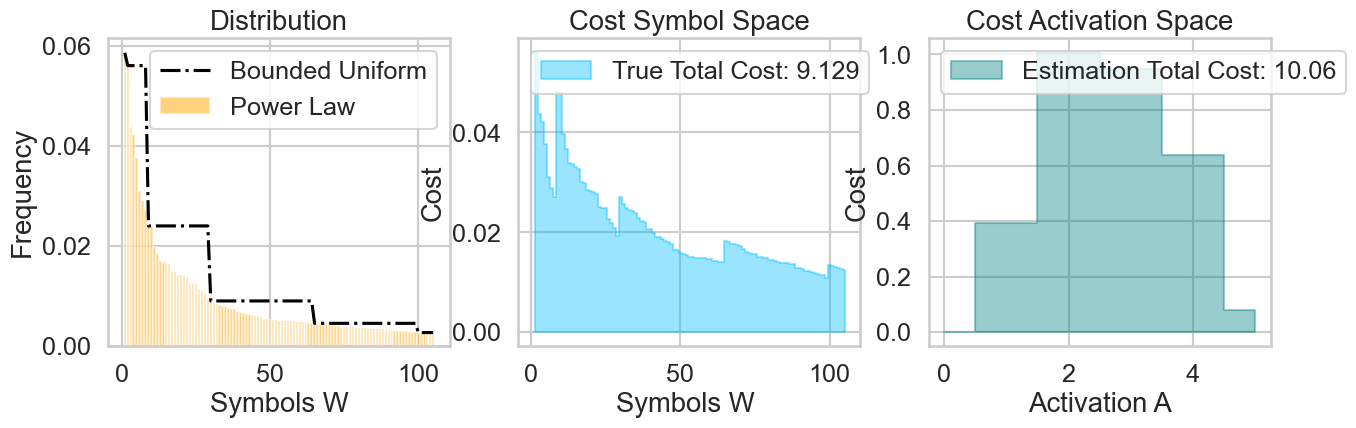

In [81]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

power_proba_bounded=np.repeat(Sup_mat_eb['z_j'],CW_used_eb)
axs[0].bar(x[:plt_range],power_d[:plt_range],alpha=0.5,label='Power Law',color='orange')
axs[0].plot(x[:plt_range],power_proba_bounded,linestyle='-.',color='black',label='Bounded Uniform')
axs[0].legend()
axs[0].set_xlabel('Symbols W')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Distribution')

label_exp="True Total Cost: "+str(Cost_total_W_eb)[0:5]
axs[1].fill_between(x[:plt_range], Sup_mat_eb['Cost_A_per_W'], step="mid", alpha=0.4,color='deepskyblue',label=label_exp)
axs[1].legend(loc='upper left')
axs[1].set_title('Cost Symbol Space')
axs[1].set_xlabel('Symbols W ')
axs[1].set_ylabel('Cost')

label_exp_bounded="Estimation Total Cost: "+str(Cost_Total_A_eb)[0:5]
axs[2].fill_between(range(0,A_eb+1), Sup_mat_eb['Cost_A_per_A'], step="mid", alpha=0.4,color='teal',label=label_exp_bounded)

axs[2].legend(loc='upper left')
axs[2].set_title('Cost Activation Space')
axs[2].set_xlabel('Activation A')
axs[2].set_ylabel('Cost')

# Compute Different Beta Uniform

In [82]:
colo = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red "#bcbd22",
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f"   # Gray
]


diff_N=20
B=[1,2,3,5,8.5,10] # the possible beta values 5.26
Current_dis=uniform_d
Current_dist_type='Uniform'

# recompute the optimal solution for Beta=1 (to get starting point for N)

N_s,A_s,CW_s,bin_s,Cost_s_A,deriv_s,Cost_s_W,Sup_mat_s=OptimalCode_general_corrected(W,N=0,beta=1,pw=Current_dis,type_dist=Current_dist_type)
print("1st run with beta 1. Optimal Code Parameters:")
print('W ',W, '/ N ',N_s,'/ A ',A_s,'/ Binomial coeff:',bin_s,'/ Sum Binom:',np.sum(bin_s),' = Symbols ',W )
print('Total Cost: ',Cost_s_W)

N_min=N_s
N_max=N_min+diff_N

beta_Cost_all_A=[]
beta_Cost_all_W=[]

beta_N_all=range(N_min,N_max)
beta_A_all=[]
beta_Deriv_all=[]

for bi in B:
    beta_c_A=[] #cost sum over A
    beta_c_W=[] #cost sum over W
    beta_a=[] #nbr active
    beta_d=[] #derivative
    beta_d_check=[] #derivative

    for ni in beta_N_all:
        Ni,Ai,CW_usedi,full_CWi,Cost_Total_Ai,dC_dN_Ai,Cost_total_Wi,Sup_mat_i=OptimalCode_general_corrected(W,ni,bi,pw=Current_dis,type_dist=Current_dist_type,test_bool=False,N_modif_bool=True)
        beta_d.append(dC_dN_Ai)
        beta_c_W.append(Cost_total_Wi)
        beta_c_A.append(Cost_Total_Ai)
        beta_a.append(Ai)
    beta_Deriv_all.append(beta_d)
    beta_Cost_all_A.append(beta_c_A)
    beta_Cost_all_W.append(beta_c_W)
    beta_A_all.append(beta_a)
    #beta_Deriv_all_2nd.append(beta_d_check)
  


---no N as input
--search lower bound N
1st run with beta 1. Optimal Code Parameters:
W  105 / N  7 / A  5 / Binomial coeff: [np.float64(1.0), np.float64(7.0), np.float64(21.0), np.float64(35.0), np.float64(35.0), np.float64(21.0)] / Sum Binom: 120.0  = Symbols  105
Total Cost:  10.085714285714284


In [83]:
## Compute beta cutoff
all_A_asso_N=beta_A_all[0]# The set of A is there indep of beta as it took all the A associated with N 
all_A_decr=[]
all__N_wi_A_decr=[]
for i,a_i in enumerate(all_A_asso_N):
    if a_i not in all_A_decr:
        all_A_decr.append(a_i)
        all__N_wi_A_decr.append((beta_N_all[i],a_i))
all__N_wi_A_decr.append((W-1,1))

B_cutoff_unif=[1]
for j in range(len(all__N_wi_A_decr)):
    if j<len(all__N_wi_A_decr)-1:
        B_cutoff_unif.append(return_beta_uniform(all__N_wi_A_decr[j][0],all__N_wi_A_decr[j][1],all__N_wi_A_decr[j+1][0],all__N_wi_A_decr[j+1][1],W))

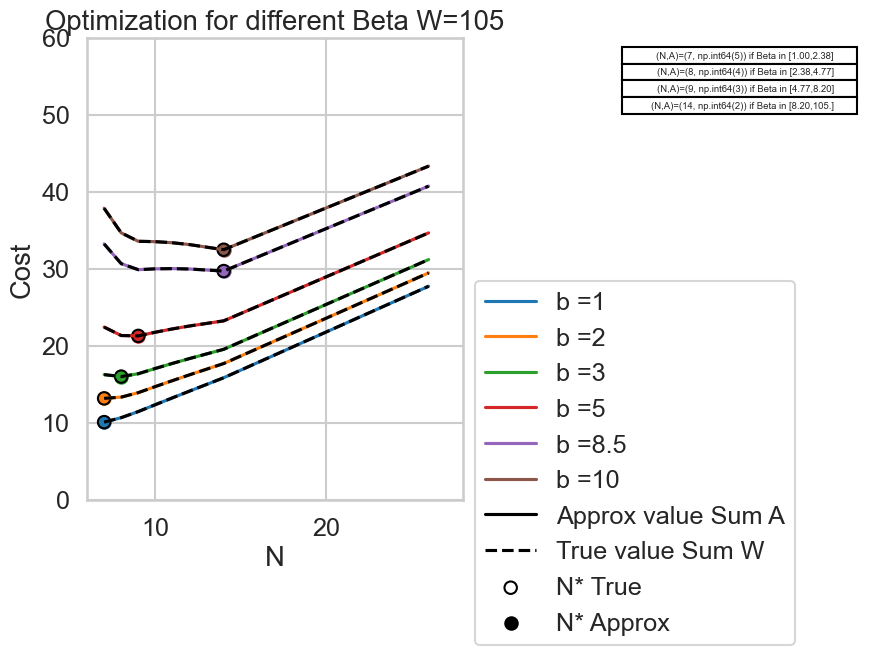

In [84]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6),gridspec_kw={'width_ratios': [2, 1]})


all_N_min_A=[]
all_N_min_W=[]

for i,bi in enumerate(B):
    lab='b ='+str(bi)
    axs[0].plot(beta_N_all,beta_Cost_all_A[i],label=lab,color=colo[i])
    axs[0].plot(beta_N_all,beta_Cost_all_W[i],color='black',linestyle='--')
    ymin_W=np.min(beta_Cost_all_W[i])
    xmin_W=N_min+np.argmin(beta_Cost_all_W[i])
    all_N_min_W.append(xmin_W)
    ymin_A=np.min(beta_Cost_all_A[i])
    xmin_A=N_min+np.argmin(beta_Cost_all_A[i])
    axs[0].scatter(xmin_A,ymin_A,s=80, edgecolors=colo[i])
    axs[0].scatter(xmin_W,ymin_W,s=80, facecolors='none', edgecolors='black')

    all_N_min_A.append(xmin_A)

    #plt.plot(N_vec,All_B_dcost_dn[i],label='Derivative digamma')
    #plt.plot(N_vec[1:],deriv_cw_sum,label='derivative Euler')
    #plt.plot(N_vec[2:],deriv2_cw_sum,label='derivative 2 Euler')
    #plt.plot(N_vec[2:],deriv2_cw_sum,label='derivative 2 Euler')

lab_approx='Approx value Sum A'
axs[0].plot([-100,-101],[-100,-101],label=lab_approx,color='black')
lab_true='True value Sum W'
axs[0].plot([-100,-101],[-100,-101],label=lab_true,color='black',linestyle='--')

axs[0].scatter(-50,-50,s=80,facecolor='none',edgecolors='black',label='N* True')
axs[0].scatter(-50,-50,s=80,facecolor='black',edgecolors='black',label='N* Approx')

axs[0].set_xlim([N_min-1,N_max+1])
axs[0].set_ylim([0,60])
axs[0].set_title('Optimization for different Beta W='+str(W))
axs[0].set_xlabel('N')
axs[0].set_ylabel('Cost')
box = axs[0].get_position()
axs[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
axs[0].legend(loc='upper left', bbox_to_anchor=(1, 0.5))
#axs[0].legend(loc='lower right')

txt_beta = [[
        "(N,A)=" + str(all__N_wi_A_decr[i])+" if Beta in "+"[" + f"{bi:.4f}"[:4] + "," + f"{B_cutoff_unif[i+1]:.4f}"[:4] + "]"
        ] for i, bi in enumerate(B_cutoff_unif) if i<len(B_cutoff_unif)-1 ]
row_label=["beta "+str(i) for i,bi in enumerate(B_cutoff_unif)]

# Add a table at the bottom of the Axes
axs[1].table(cellText=txt_beta,
                      loc='best')
axs[1].set_axis_off()
#axs[1].remove()

In [85]:
all_indx_deriv_min=Min_sign_flip_close(B,beta_Deriv_all)

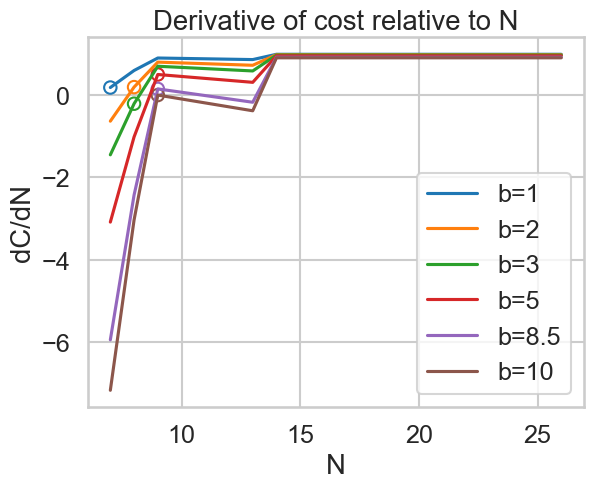

In [86]:
all_N_mi_fro_deriv=[]
for i,bi in enumerate(B):
    lab='b='+str(bi)
    plt.plot(beta_N_all,beta_Deriv_all[i],label=lab,color=colo[i])
    ymin=beta_Deriv_all[i][int(all_indx_deriv_min[i])]
    xmin=N_min+all_indx_deriv_min[i]
    all_N_mi_fro_deriv.append(xmin)
    plt.scatter(xmin,ymin,s=80, facecolors='none', edgecolors=colo[i])

plt.title('Derivative of cost relative to N')
plt.xlabel('N')
plt.ylabel('dC/dN')
plt.legend()

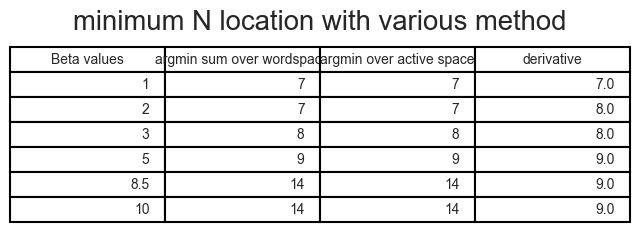

In [87]:
### This small section has been modified using AI
cell_text = []
for i in range(len(all_N_min_W)):
    # Create a row with three columns
    row = [
         f"{B[i]}",   # Format to one decimal place
         f"{all_N_min_W[i]}",   # Format to one decimal place
         f"{all_N_min_A[i]}",
         f"{all_N_mi_fro_deriv[i]}"
    ]
    cell_text.append(row)
# Define column headers
columns = [
    "Beta values",
    "argmin sum over wordspace",
    "argmin over active space",
    "derivative"
]

# Create a figure and an axis for the table (adjust size as needed)
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')  # Hide axes

# Create the table in the center of the axis
table=ax.table(cellText=cell_text, colLabels=columns, loc='center')

# Optionally, adjust table styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)  # Adjust vertical scaling if needed

# Add a title above the table
plt.title("minimum N location with various method", pad=20)

plt.show()

## Generated Gamma Distribution Function Data

## Test recover the true fit True True


Text(0, 0.5, 'Frequency')

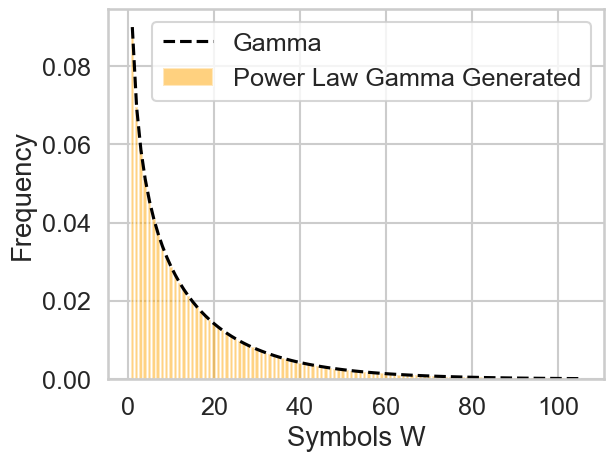

In [88]:
## fits Gamma 

alpha_test=0.7
theta_test=20
power_dis_fake=np.array(gamma_f(range(1,W+1),alpha_test,theta_test))


gamma_fit_test=so.curve_fit(gamma_f,x,power_dis_fake)
print("## Test recover the true fit",np.isclose(gamma_fit_test[0][0],alpha_test),np.isclose(gamma_fit_test[0][1],theta_test))

## Plot Two distributions
plt_range=W
plt.bar(x[:plt_range],power_dis_fake[:plt_range],alpha=0.5,label='Power Law Gamma Generated',color='orange')
plt.plot(x[:plt_range],gamma_f(x,gamma_fit_test[0][0],gamma_fit_test[0][1]),linestyle='--',color='black',label='Gamma')
plt.legend()
plt.xlabel('Symbols W')
plt.ylabel('Frequency')

In [89]:
## Gamma with Gamma distribution

N_g_g,A_g_g,CW_used_g_g,full_CW_g_g,Cost_Total_A_g_g,dC_dN_A_g_g,Cost_total_W_g_g,Sup_mat_g_g=OptimalCode_general_corrected(W,N=0,beta=1,pw=power_dis_fake,type_dist='Gamma',test_bool=True,N_modif_bool=True)



---no N as input
--search lower bound N
## Test sum pw = 1: False
## Test Correct implementation of P(0<=x<=Xf)
Step by step:  0.9989312212705854
One step calculation:  0.9989312212705855
## Test Correct implementation of P(0<=x<=W)
Step by step:  0.9976572495556164
One step calculation:  0.9976572495556165
## Test Sum W vs Sum A: False


/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:108: RuntimeWarning: divide by zero encountered in scalar power
  kap=(-pow(x_interm,gam_par_zeta-1)*np.exp(-x_interm))/gamma(gam_par_zeta)
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:109: RuntimeWarning: invalid value encountered in scalar multiply
  return kap*chain


Text(0, 0.5, 'Cost')

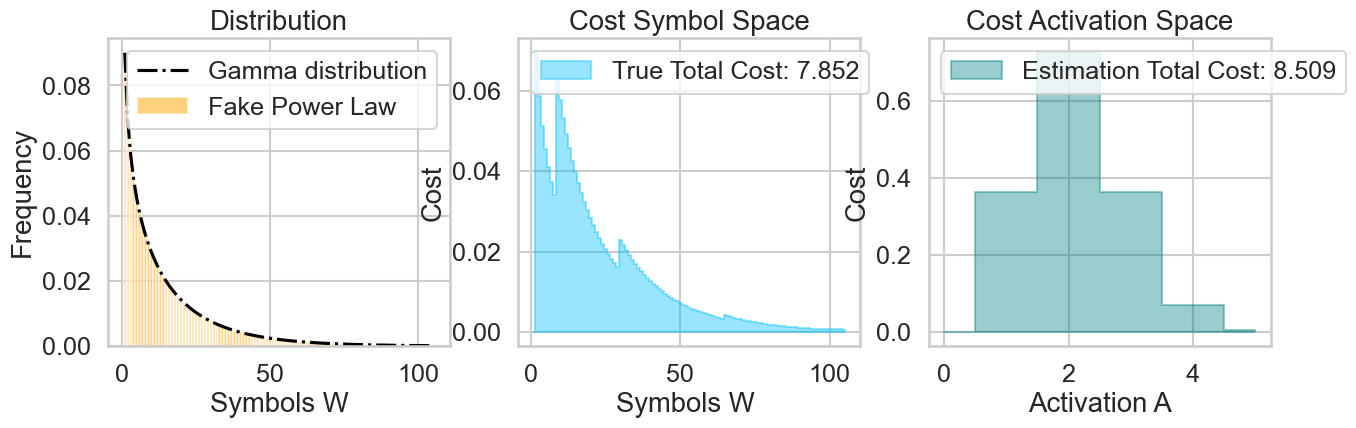

In [90]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(x[:plt_range],power_dis_fake[:plt_range],alpha=0.5,label='Fake Power Law',color='orange')
axs[0].plot(x[:plt_range],gamma_f(x[:plt_range],Sup_mat_g_g['gam_param'][0],Sup_mat_g_g['gam_param'][1]),linestyle='-.',color='black',label='Gamma distribution')
axs[0].legend()
axs[0].set_xlabel('Symbols W')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Distribution')

label_exp_g="True Total Cost: "+str(Cost_total_W_g_g)[0:5]
axs[1].fill_between(x[:plt_range], Sup_mat_g_g['Cost_A_per_W'], step="mid", alpha=0.4,color='deepskyblue',label=label_exp_g)
axs[1].legend(loc='upper left')
axs[1].set_title('Cost Symbol Space')
axs[1].set_xlabel('Symbols W ')
axs[1].set_ylabel('Cost')

label_exp_gam_g="Estimation Total Cost: "+str(Cost_Total_A_g_g)[0:5]
axs[2].fill_between(range(0,A_g_g+1), Sup_mat_g_g['Cost_A_per_A'], step="mid", alpha=0.4,color='teal',label=label_exp_gam_g)

axs[2].legend(loc='upper left')
axs[2].set_title('Cost Activation Space')
axs[2].set_xlabel('Activation A')
axs[2].set_ylabel('Cost')

In [91]:
colo = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red "#bcbd22",
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f"   # Gray
]


diff_N=20
B=[1,4,8,12,20,30] # the possible beta values
Current_dis=power_dis_fake
Current_dist_type='Gamma'

# recompute the optimal solution for Beta=1 (to get starting point for N)
N_s,A_s,CW_s,bin_s,Cost_s_A,deriv_s,Cost_s_W,Sup_mat_s=OptimalCode_general_corrected(W,N=0,beta=1,pw=Current_dis,type_dist=Current_dist_type)
print("1st run with beta 1. Optimal Code Parameters:")
print('W ',W, '/ N ',N_s,'/ A ',A_s,'/ Binomial coeff:',bin_s,'/ Sum Binom:',np.sum(bin_s),' = Symbols ',W )
print('Total Cost: ',Cost_s_W)

N_min=N_s
N_max=N_min+diff_N

beta_Cost_all_A=[]
beta_Cost_all_W=[]

beta_N_all=range(N_min,N_max)
beta_A_all=[]
beta_Deriv_all=[]

for bi in B:
    beta_c_A=[] #cost sum over A
    beta_c_W=[] #cost sum over W
    beta_a=[] #nbr active
    beta_d=[] #derivative
    beta_d_check=[] #derivative

    for ni in beta_N_all:
        Ni,Ai,CW_usedi,full_CWi,Cost_Total_Ai,dC_dN_Ai,Cost_total_Wi,Sup_mat_i=OptimalCode_general_corrected(W,ni,bi,pw=Current_dis,type_dist=Current_dist_type,test_bool=False,N_modif_bool=True)
        beta_d.append(dC_dN_Ai)
        beta_c_W.append(Cost_total_Wi)
        beta_c_A.append(Cost_Total_Ai)
        beta_a.append(Ai)
    beta_Deriv_all.append(beta_d)
    beta_Cost_all_A.append(beta_c_A)
    beta_Cost_all_W.append(beta_c_W)
    beta_A_all.append(beta_a)
    #beta_Deriv_all_2nd.append(beta_d_check)
  


---no N as input
--search lower bound N
1st run with beta 1. Optimal Code Parameters:
W  105 / N  7 / A  5 / Binomial coeff: [np.float64(1.0), np.float64(7.0), np.float64(21.0), np.float64(35.0), np.float64(35.0), np.float64(21.0)] / Sum Binom: 120.0  = Symbols  105
Total Cost:  7.852420208628422


/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:108: RuntimeWarning: divide by zero encountered in scalar power
  kap=(-pow(x_interm,gam_par_zeta-1)*np.exp(-x_interm))/gamma(gam_par_zeta)
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:109: RuntimeWarning: invalid value encountered in scalar multiply
  return kap*chain


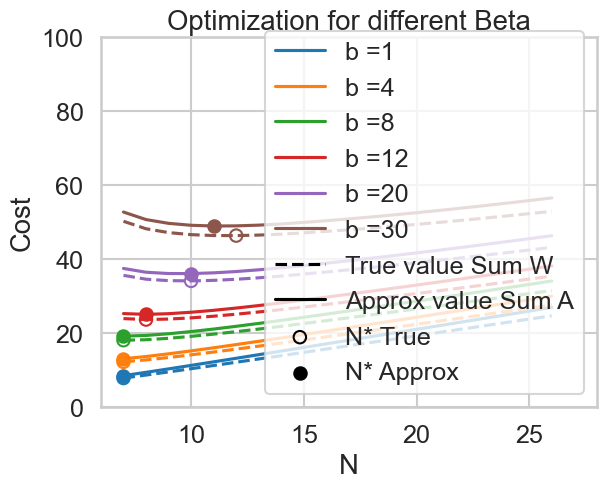

In [92]:
all_N_min_A=[]
all_N_min_W=[]

for i,bi in enumerate(B):
    lab='b ='+str(bi)
    plt.plot(beta_N_all,beta_Cost_all_A[i],label=lab,color=colo[i])
    plt.plot(beta_N_all,beta_Cost_all_W[i],color=colo[i],linestyle='--')
    ymin_W=np.min(beta_Cost_all_W[i])
    xmin_W=N_min+np.argmin(beta_Cost_all_W[i])
    all_N_min_W.append(xmin_W)
    plt.scatter(xmin_W,ymin_W,s=80, facecolors='none', edgecolors=colo[i])
    ymin_A=np.min(beta_Cost_all_A[i])
    xmin_A=N_min+np.argmin(beta_Cost_all_A[i])
    plt.scatter(xmin_A,ymin_A,s=80, edgecolors=colo[i])
    all_N_min_A.append(xmin_A)

    #plt.plot(N_vec,All_B_dcost_dn[i],label='Derivative digamma')
    #plt.plot(N_vec[1:],deriv_cw_sum,label='derivative Euler')
    #plt.plot(N_vec[2:],deriv2_cw_sum,label='derivative 2 Euler')
    #plt.plot(N_vec[2:],deriv2_cw_sum,label='derivative 2 Euler')
lab_true='True value Sum W'
plt.plot([-100,-101],[-100,-101],label=lab_true,color='black',linestyle='--')
lab_approx='Approx value Sum A'
plt.plot([-100,-101],[-100,-101],label=lab_approx,color='black')

plt.scatter(-50,-50,s=80,facecolor='none',edgecolors='black',label='N* True')
plt.scatter(-50,-50,s=80,facecolor='black',edgecolors='black',label='N* Approx')

plt.xlim([N_min-1,N_max+1])
plt.ylim([0,100])
plt.title('Optimization for different Beta')
plt.xlabel('N')
plt.ylabel('Cost')
plt.legend(loc='lower right')

# Approximated Gamma Distribution using Spakeaspear

In [93]:
## Power law Bounded

N_g,A_g,CW_used_g,full_CW_g,Cost_Total_A_g,dC_dN_A_g,Cost_total_W_g,Sup_mat_g=OptimalCode_general_corrected(W,N=0,beta=1,pw=power_d,type_dist='Gamma',test_bool=True,N_modif_bool=False)
print(Cost_Total_A_g)
print(Cost_total_W_g)


---no N as input
--search lower bound N
## Test sum pw = 1: True
## Test Correct implementation of P(0<=x<=Xf)
Step by step:  0.979044292677654
One step calculation:  0.979044292677654
## Test Correct implementation of P(0<=x<=W)
Step by step:  0.9680281530222089
One step calculation:  0.9680281530222088
## Test Sum W vs Sum A: False
8.83184452559837
9.129442785183912


/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:108: RuntimeWarning: divide by zero encountered in scalar power
  kap=(-pow(x_interm,gam_par_zeta-1)*np.exp(-x_interm))/gamma(gam_par_zeta)
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:109: RuntimeWarning: invalid value encountered in scalar multiply
  return kap*chain


Text(0, 0.5, 'Cost')

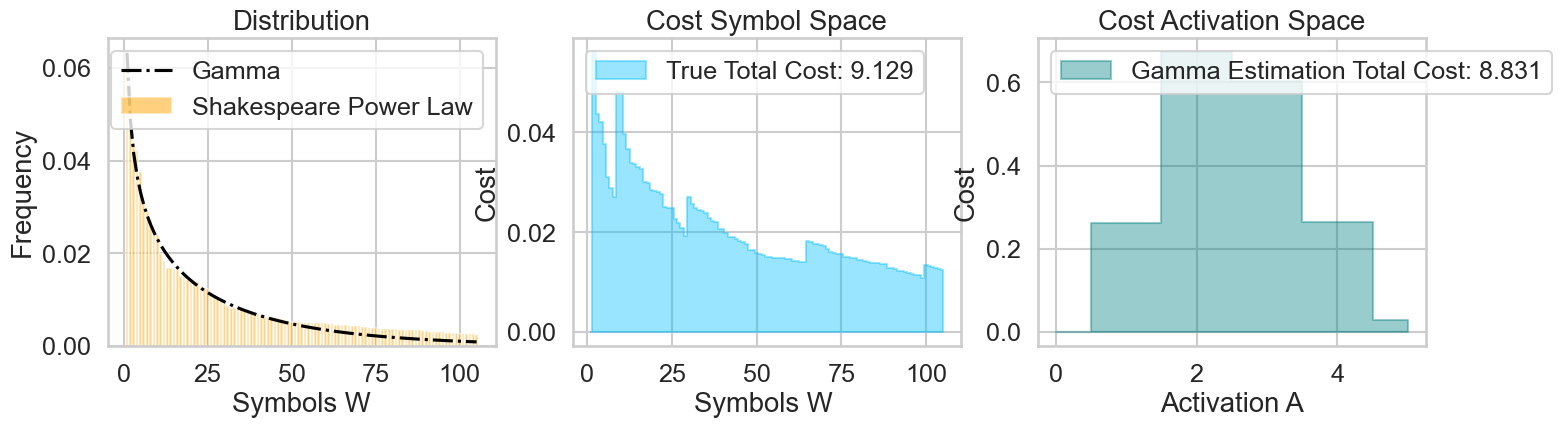

In [94]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4))

axs[0].bar(x[:plt_range],power_d[:plt_range],alpha=0.5,label='Shakespeare Power Law',color='orange')
axs[0].plot(x[:plt_range],gamma_f(x[:plt_range],Sup_mat_g['gam_param'][0],Sup_mat_g['gam_param'][1]),linestyle='-.',color='black',label='Gamma')
axs[0].legend()
axs[0].set_xlabel('Symbols W')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Distribution')

label_exp="True Total Cost: "+str(Cost_total_W_g)[0:5]
axs[1].fill_between(x[:plt_range], Sup_mat_g['Cost_A_per_W'], step="mid", alpha=0.4,color='deepskyblue',label=label_exp)
axs[1].legend(loc='upper left')
axs[1].set_title('Cost Symbol Space')
axs[1].set_xlabel('Symbols W ')
axs[1].set_ylabel('Cost')

label_exp_gam="Gamma Estimation Total Cost: "+str(Cost_Total_A_g)[0:5]
axs[2].fill_between(range(0,A_g+1), Sup_mat_g['Cost_A_per_A'], step="mid", alpha=0.4,color='teal',label=label_exp_gam)

axs[2].legend(loc='upper left')
axs[2].set_title('Cost Activation Space')
axs[2].set_xlabel('Activation A')
axs[2].set_ylabel('Cost')

In [95]:
colo = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red "#bcbd22",
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f"   # Gray
]


diff_N=20
B=[1,4,5,8,9,15,16] # the possible beta values
Current_dis=power_d
Current_dist_type='Gamma'

# recompute the optimal solution for Beta=1 (to get starting point for N)
N_s,A_s,CW_s,bin_s,Cost_s_A,deriv_s,Cost_s_W,Sup_mat_s=OptimalCode_general_corrected(W,N=0,beta=1,pw=Current_dis,type_dist=Current_dist_type)
print("1st run with beta 1. Optimal Code Parameters:")
print('W ',W, '/ N ',N_s,'/ A ',A_s,'/ Binomial coeff:',bin_s,'/ Sum Binom:',np.sum(bin_s),' = Symbols ',W )
print('Total Cost: ',Cost_s_W)

N_min=N_s
N_max=N_min+diff_N

beta_Cost_all_A=[]
beta_Cost_all_W=[]

beta_N_all=range(N_min,N_max)
beta_A_all=[]
beta_Deriv_all=[]
beta_cw_used_all=[]

for bi in B:
    beta_c_A=[] #cost sum over A
    beta_c_W=[] #cost sum over W
    beta_a=[] #nbr active
    beta_d=[] #derivative
    beta_d_check=[] #derivative
    beta_cw_used=[]

    for ni in beta_N_all:
        Ni,Ai,CW_usedi,full_CWi,Cost_Total_Ai,dC_dN_Ai,Cost_total_Wi,Sup_mat_i=OptimalCode_general_corrected(W,ni,bi,pw=Current_dis,type_dist=Current_dist_type,test_bool=False,N_modif_bool=False)
        beta_d.append(dC_dN_Ai)
        beta_c_W.append(Cost_total_Wi)
        beta_c_A.append(Cost_Total_Ai)
        beta_a.append(Ai)
        beta_cw_used.append(CW_usedi)
    beta_Deriv_all.append(beta_d)
    beta_Cost_all_A.append(beta_c_A)
    beta_Cost_all_W.append(beta_c_W)
    beta_A_all.append(beta_a)
    beta_cw_used_all.append(beta_cw_used)
    #beta_Deriv_all_2nd.append(beta_d_check)
  


---no N as input
--search lower bound N
1st run with beta 1. Optimal Code Parameters:
W  105 / N  7 / A  5 / Binomial coeff: [np.float64(1.0), np.float64(7.0), np.float64(21.0), np.float64(35.0), np.float64(35.0), np.float64(21.0)] / Sum Binom: 120.0  = Symbols  105
Total Cost:  9.129442785183912


/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:108: RuntimeWarning: divide by zero encountered in scalar power
  kap=(-pow(x_interm,gam_par_zeta-1)*np.exp(-x_interm))/gamma(gam_par_zeta)
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56106/3770872374.py:109: RuntimeWarning: invalid value encountered in scalar multiply
  return kap*chain


In [96]:
## Compute beta cutoff Gamma Approximation & True
all_A_asso_N=beta_A_all[0]# The set of A is there indep of beta as it took all the A associated with N 
all_cw_used_asso_N=beta_cw_used_all[0]# The set of CW is there indep of beta as it depends on N and A

all_A_decr=[]
all__N_wi_A_decr=[]
all_floors_wi_A_decr=[]
for i,a_i in enumerate(all_A_asso_N):
    if a_i not in all_A_decr:
        all_A_decr.append(a_i)
        all__N_wi_A_decr.append((beta_N_all[i],a_i))
        all_floors_wi_A_decr.append(all_cw_used_asso_N[i]) # Save all the "floors" which are the CW_used
# Add last floor (since have not run all possible N (computation efficiency only loop over 20 N))
all__N_wi_A_decr.append((W-1,1))
all_floors_wi_A_decr.append([1,W-1])

B_cutoff_gamma=[1]
for j in range(len(all__N_wi_A_decr)):
    if j<len(all__N_wi_A_decr)-1:
        B_cutoff_gamma.append(return_beta_gamma_approx(all__N_wi_A_decr[j][0],all__N_wi_A_decr[j][1],all__N_wi_A_decr[j+1][0],all__N_wi_A_decr[j+1][1],W,Sup_mat_g['gam_param']))

In [97]:
## Compute beta cutoff Gamma TRUE

B_cutoff_gamma_true=[1]
for j in range(len(all__N_wi_A_decr)):
    if j<len(all__N_wi_A_decr)-1:
        B_cutoff_gamma_true.append(return_beta_gamma_true(all__N_wi_A_decr[j][0],all__N_wi_A_decr[j][1],all_floors_wi_A_decr[j],all__N_wi_A_decr[j+1][0],all__N_wi_A_decr[j+1][1],all_floors_wi_A_decr[j+1],power_d))


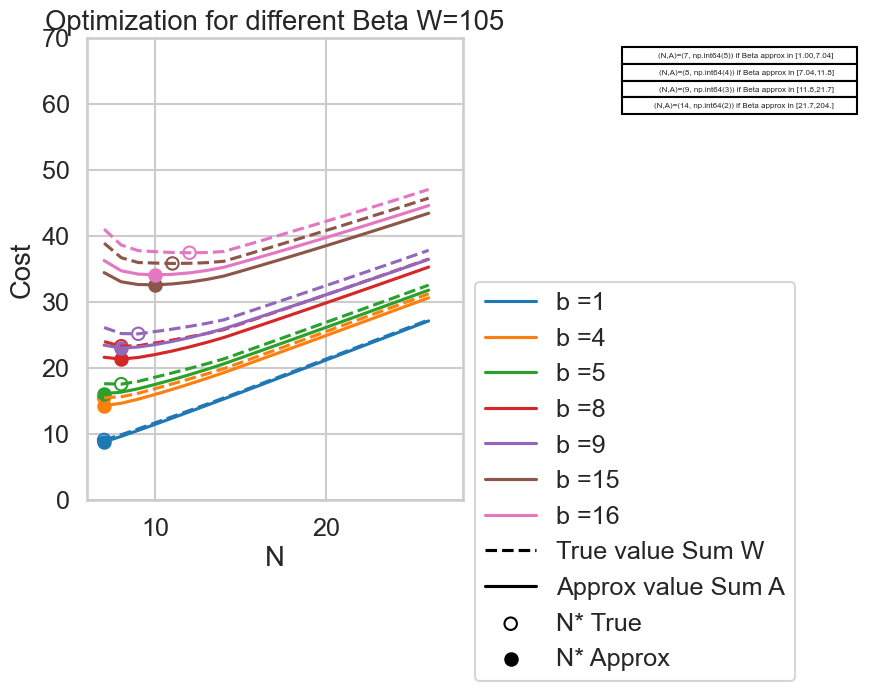

In [98]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6),gridspec_kw={'width_ratios': [2, 1]})

all_N_min_A=[]
all_N_min_W=[]

for i,bi in enumerate(B):
    lab='b ='+str(bi)
    axs[0].plot(beta_N_all,beta_Cost_all_A[i],label=lab,color=colo[i])
    axs[0].plot(beta_N_all,beta_Cost_all_W[i],color=colo[i],linestyle='--')
    ymin_W=np.min(beta_Cost_all_W[i])
    xmin_W=N_min+np.argmin(beta_Cost_all_W[i])
    all_N_min_W.append(xmin_W)
    axs[0].scatter(xmin_W,ymin_W,s=80, facecolors='none', edgecolors=colo[i])
    ymin_A=np.min(beta_Cost_all_A[i])
    xmin_A=N_min+np.argmin(beta_Cost_all_A[i])
    axs[0].scatter(xmin_A,ymin_A,s=80, edgecolors=colo[i])
    all_N_min_A.append(xmin_A)

    #plt.plot(N_vec,All_B_dcost_dn[i],label='Derivative digamma')
    #plt.plot(N_vec[1:],deriv_cw_sum,label='derivative Euler')
    #plt.plot(N_vec[2:],deriv2_cw_sum,label='derivative 2 Euler')
    #plt.plot(N_vec[2:],deriv2_cw_sum,label='derivative 2 Euler')
lab_true='True value Sum W'
axs[0].plot([-100,-101],[-100,-101],label=lab_true,color='black',linestyle='--')
lab_approx='Approx value Sum A'
axs[0].plot([-100,-101],[-100,-101],label=lab_approx,color='black')

axs[0].scatter(-50,-50,s=80,facecolor='none',edgecolors='black',label='N* True')
axs[0].scatter(-50,-50,s=80,facecolor='black',edgecolors='black',label='N* Approx')

axs[0].set_xlim([N_min-1,N_max+1])
axs[0].set_ylim([0,70])
axs[0].set_title('Optimization for different Beta W='+str(W))
axs[0].set_xlabel('N')
axs[0].set_ylabel('Cost')
box = axs[0].get_position()
axs[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
axs[0].legend(loc='upper left', bbox_to_anchor=(1, 0.5))
#axs[0].legend(loc='lower right')

txt_beta = [[
        "(N,A)=" + str(all__N_wi_A_decr[i])+" if Beta approx in "+"[" + f"{bi:.4f}"[:4] + "," + f"{B_cutoff_gamma[i+1]:.4f}"[:4] + "]"
        ] for i, bi in enumerate(B_cutoff_gamma) if i<len(B_cutoff_gamma)-1 ]
row_label=["beta "+str(i) for i,bi in enumerate(B_cutoff_gamma)]

# Add a table at the bottom of the Axes
axs[1].table(cellText=txt_beta,
                      loc='best')
axs[1].set_axis_off()
#axs[1].remove()

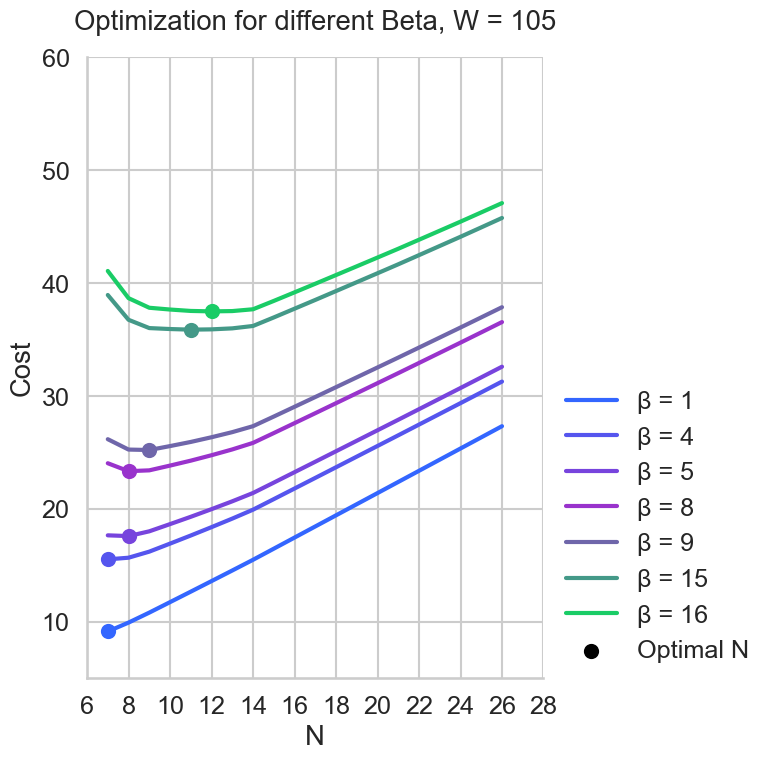

In [99]:
#### Imported from GPT

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ---- Style Setup ----
mpl.rcParams['text.usetex'] = False
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

sns.set_context("talk", font_scale=1.1)
sns.set_style("whitegrid")

# ---- Custom vivid gradient: blue → purple → green ----
colors = [(0.2, 0.4, 1.0),    # vivid blue
          (0.6, 0.2, 0.8),    # purple
          (0.1, 0.8, 0.4)]    # green

custom_cmap = LinearSegmentedColormap.from_list("blue_purple_green", colors, N=len(B))
colo = [custom_cmap(i / (len(B)-1)) for i in range(len(B))]

# ---- Plotting ----
fig, ax = plt.subplots(figsize=(7, 8))

for i, bi in enumerate(B):
    label = f"β = {bi}"
    ax.plot(beta_N_all, beta_Cost_all_W[i],
            linestyle='-',
            color=colo[i],
            linewidth=3,
            label=label)

    # Minimum marker
    ymin_W = np.min(beta_Cost_all_W[i])
    xmin_W = N_min + np.argmin(beta_Cost_all_W[i])
    ax.scatter(xmin_W, ymin_W, s=80, facecolors=colo[i],
               edgecolors=colo[i], marker='o', linewidth=2)

# Dummy entries for legend
ax.scatter([], [], s=80, facecolors='black', edgecolors='black',
           marker='o', linewidth=2, label='Optimal N')

ax.set_xlim([N_min - 1, N_max + 1])
ax.set_ylim([5, 60])
ax.set_title(f"Optimization for different Beta, W = {W}", pad=20)
ax.set_xlabel("N")
ax.set_ylabel("Cost")
ax.set_xticks(np.linspace(N_min - 1, N_max + 1, 12))
# Legend
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5), frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

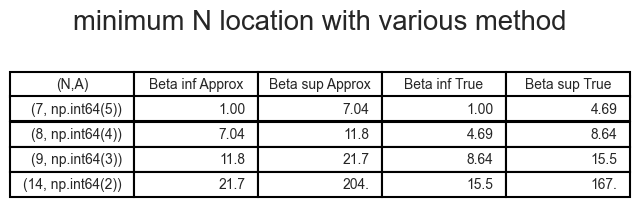

In [100]:
## Plot the Beta cutt off true and approx
Beta_Approx=B_cutoff_gamma
cell_text_Beta_Approx = [[
         str(all__N_wi_A_decr[i]),
         f"{Beta_Approx[i]:.4f}"[:4],   # Format to one decimal place
         f"{Beta_Approx[i+1]:.4f}"[:4],   # Format to one decimal place
         f"{B_cutoff_gamma_true[i]:.4f}"[:4],   # Format to one decimal place
         f"{B_cutoff_gamma_true[i+1]:.4f}"[:4],   # Format to one decimal place
    ] for i, bi in enumerate(Beta_Approx) if i<len(Beta_Approx)-1 ]

# Define column headers
columns_beta = [
    "(N,A)",
    "Beta inf Approx",
    "Beta sup Approx",
    "Beta inf True",
    "Beta sup True",
]

# Create a figure and an axis for the table (adjust size as needed)
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')  # Hide axes

# Create the table in the center of the axis
table=ax.table(cellText=cell_text_Beta_Approx, colLabels=columns_beta, loc='center')

# Optionally, adjust table styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)  # Adjust vertical scaling if needed

# Add a title above the table
plt.title("minimum N location with various method", pad=20)

plt.show()